# 01 · Exploring Calgary's 311 requests

Stage 2 of the *MLOps + AIOps on AWS* series. Before training anything: what does the data
look like over a year, and does "busy" mean "late"?

Runs locally on the Stage 1 snapshot (2,911,486 requests since 2021-01-01, as of
2026-09-23). No AWS calls, no cost. Figures are saved to `notebooks/figures/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # run from code/notebooks/
from src.features.build_labels import build_training_labels

# The frozen snapshot from Stage 1. To recreate it without the API:
#   python -m src.ingest.socrata_pull replay --asof 2026-09-23
raw = pd.read_parquet("../data/processed/311").drop(columns=["year", "month"])
req = pd.to_datetime(raw["requested_date"], utc=True, format="ISO8601").dt.tz_localize(None)
print(f"{len(raw):,} requests, {req.min():%Y-%m-%d} to {req.max():%Y-%m-%d}")


2,911,486 requests, 2021-01-01 to 2026-09-22


In [2]:
# Chart style: one small set of tokens, reused by every figure in this series.
import matplotlib as mpl
import matplotlib.pyplot as plt

INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE, GRID, AXIS = "#fcfcfb", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
POLE_UP, POLE_DOWN = "#e34948", "#2a78d6"  # diverging pair (red / blue)
SOURCE = "Data: City of Calgary 311 Service Requests, Open Government Licence – City of Calgary"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True,  # gridlines behind bars
    "lines.linewidth": 2, "legend.frameon": False,
})

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


def finish(fig, title, subtitle, name):
    """Left-aligned title and subtitle, a source line, then save a Medium-width PNG."""
    fig.text(0.01, 0.985, title, ha="left", va="top", fontsize=14, weight="bold", color=INK)
    fig.text(0.01, 0.925, subtitle, ha="left", va="top", fontsize=10, color=INK_2)
    fig.text(0.01, 0.01, SOURCE, ha="left", va="bottom", fontsize=7.5, color=MUTED)
    fig.savefig(FIGURES / name, dpi=200)
    plt.show()


## 1. Every category has its own year

Share of each category's requests that arrive in each calendar month, over the five full
years 2021–2025. Each line sums to 100%, so categories of very different sizes share one
axis.

In [3]:
full = raw[(req >= "2021-01-01") & (req < "2026-01-01")].assign(month=req.dt.month)
shapes = {
    "Snow and ice on sidewalks": "Bylaw - Snow and Ice on Sidewalk",
    "Long grass and weeds": "Bylaw - Long Grass - Weeds Infraction",
    "Potholes": "Roads - Pothole Maintenance",
    "Garbage carts": "WRS - Cart Management",
}
share = pd.DataFrame({
    label: full.loc[full["service_name"] == name].groupby("month").size().reindex(range(1, 13), fill_value=0)
    for label, name in shapes.items()
})
share = share / share.sum() * 100
share.round(1)

,Snow and ice on sidewalks,Long grass and weeds,Potholes,Garbage carts
month,,,,
1,26.5,0.0,2.1,8.8
2,18.4,0.0,3.6,6.4
3,13.8,0.0,11.3,7.1
4,0.8,0.1,18.1,8.5
5,0.0,7.7,18.0,9.8
6,0.0,28.3,13.0,9.4
7,0.0,31.6,11.0,9.8
8,0.0,21.7,8.0,9.6
9,0.0,8.0,6.7,8.7


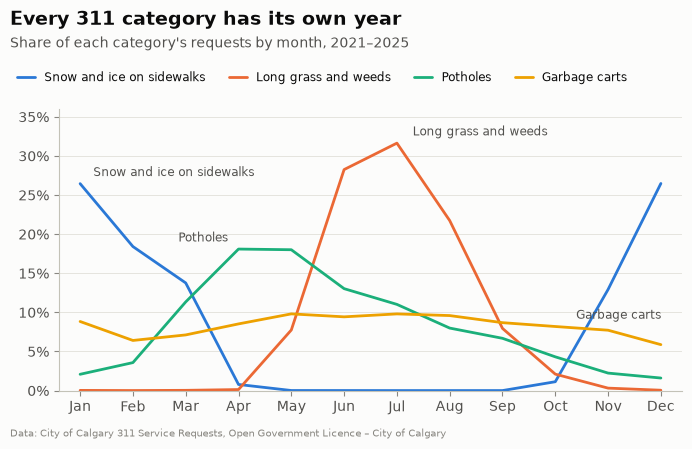

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.4))
fig.subplots_adjust(left=0.08, right=0.97, top=0.76, bottom=0.12)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# each line's direct label sits beside its own peak, where the lines don't cross
label_at = {"Snow and ice on sidewalks": (1, "left", 0.25), "Long grass and weeds": (7, "left", 0.3),
            "Potholes": (4, "right", -0.2), "Garbage carts": (10, "center", 1.2)}
for color, label in zip(SERIES, share.columns):
    ax.plot(range(1, 13), share[label], color=color, label=label, solid_capstyle="round")
    m, ha, dx = label_at[label]
    ax.text(m + dx, share[label].loc[m] + 0.6, label, color=INK_2, ha=ha, va="bottom", fontsize=8.5)
ax.set_xticks(range(1, 13), months)
ax.set_xlim(0.6, 12.4)
ax.set_ylim(0, 36)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
ax.grid(axis="x", visible=False)
fig.legend(loc="upper left", ncols=4, fontsize=8.5, bbox_to_anchor=(0.005, 0.87), handlelength=1.5)
finish(fig, "Every 311 category has its own year",
       "Share of each category's requests by month, 2021–2025", "01-seasonal-shapes.png")

Snow and ice peaks at a quarter of its year in January and vanishes from May to
August; weeds are the mirror image, peaking in July. Potholes spike in the spring thaw,
and garbage carts barely move. A model that knows the month knows a lot about *which*
requests arrive, which is why `req_month` ranks second in the baseline's feature
importance.

## 2. Does "busy" mean "late"?

For the 20 busiest categories: across months, is a category's request volume correlated
with the share of its requests that run late? Labels use the per-category 75th-percentile
threshold, with open requests past their threshold counted as late (see
`src/features/build_labels.py`). Months with fewer than 50 labelled requests are left out.

In [5]:
train, test, thresholds = build_training_labels(raw)
labelled = pd.concat([train, test], ignore_index=True)
labelled["ym"] = pd.to_datetime(labelled["requested_date"], utc=True, format="ISO8601").dt.tz_localize(None).dt.to_period("M")

rows = []
for name in labelled["service_name"].value_counts().head(20).index:
    monthly = labelled.loc[labelled["service_name"] == name].groupby("ym").agg(n=("breach", "size"), late=("breach", "mean"))
    monthly = monthly[monthly["n"] >= 50]
    if len(monthly) >= 24:
        rows.append((name, len(monthly), np.corrcoef(monthly["n"], monthly["late"])[0, 1]))
busy = pd.DataFrame(rows, columns=["category", "months", "r"]).sort_values("r")
busy.round(2)

,category,months,r
8,WRS - Recycling - Blue Cart,61,-0.24
13,Roads - Pothole Maintenance,59,-0.21
7,Bylaw - Long Grass - Weeds Infraction,32,-0.18
1,Finance - Property Tax Account Inquiry,33,-0.11
9,Bylaw - Material on Public Property,61,-0.05
16,Roads - Snow and Ice Control,32,0.00
4,Corporate - Graffiti Concerns,61,0.04
15,Corporate - Encampment Concerns,61,0.04
17,WATS - Sewage Back-up,61,0.05
11,WRS - Compost - Green Cart,61,0.08


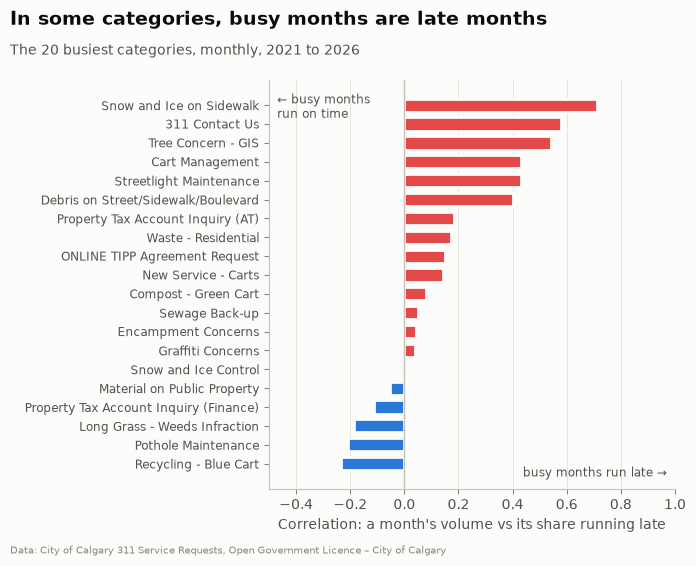

In [6]:
def short(name):
    """Drop the department prefix, unless two categories would then look identical."""
    dept, _, rest = name.partition(" - ")
    duplicate = sum(c.partition(" - ")[2] == rest for c in busy["category"]) > 1
    return f"{rest} ({dept})" if duplicate else (rest or name)

fig, ax = plt.subplots(figsize=(7, 5.6))
fig.subplots_adjust(left=0.38, right=0.96, top=0.86, bottom=0.13)
colors = [POLE_UP if r > 0 else POLE_DOWN for r in busy["r"]]
ax.barh(range(len(busy)), busy["r"], color=colors, height=0.7, edgecolor=SURFACE, linewidth=2)
ax.set_yticks(range(len(busy)), [short(c) for c in busy["category"]], fontsize=8.5)
ax.axvline(0, color=AXIS, linewidth=1)
ax.set_xlim(-0.5, 1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Correlation: a month's volume vs its share running late")
# direction notes in the empty space on each side of zero
ax.text(0.02, 0.97, "← busy months\nrun on time", transform=ax.transAxes, va="top", color=INK_2, fontsize=8.5)
ax.text(0.98, 0.03, "busy months run late →", transform=ax.transAxes, ha="right", color=INK_2, fontsize=8.5)
finish(fig, "In some categories, busy months are late months",
       "The 20 busiest categories, monthly, 2021 to 2026", "01-busy-vs-late.png")

Sidewalk snow and ice is the clearest case: in a heavy month, far more requests run
late. Potholes, weeds and blue carts go the other way: their busy months are *not* later,
which looks like the City staffing for a peak it knows is coming. This is correlation
across months, not proof of cause; weather, staffing and policy changes all move both
numbers.

At the level of single requests the effect is real but modest: when a category's own
30-day backlog is in its highest fifth, 24.8% of its requests run late, against 21.6% in
its lowest fifth. That backlog is the `cat_open_30d` feature, the baseline's
third-strongest.